In [52]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [54]:
# char to int , int to char mapping
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)



{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [55]:
import random
random.seed(42)
random.shuffle(words)

In [94]:
# build the dataset
block_size = 8 # artik bigrami geride biraktik 8li karakter islemeye gectik

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [57]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [58]:
# kafamdaki soru su: cogu isim 8 harften az oldugu icin block_size cok buyuk degil mi? Bu kasitli olarak mi yapilmis ve ne anlama geliyor

Kasıtlı mı? Evet, iki sebeple:                                                
  1. Kapsam: İsimlerin çoğu 8 harften kısa (senin çıktında en uzunu 15). Böylece cogu isimleri hatirlayabiliyor baglami kopmadan

  2. WaveNet için 2'nin kuvveti: 8 → 4 → 2 → 1, yani tam 3 katmanda temiz bir ağaç oluşuyor. 6 ya da 10 olsaydı çiftler tam bölünmezdi.

##task 1
1. Hafta 4'te yazdığın MLP + BatchNorm kodunu sınıflara topla: Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential. Model tek bir Sequential olsun, eğitim döngüsü içindeki katmanların adını bilmesin. Loss eğrisi çizimini videodaki gibi düzelt. (1:40 - 17:11)

In [59]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:

      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []


In [60]:
torch.manual_seed(42) # generator yerine global seed kullaniyoruz

In [61]:
n_embd = 10
n_hidden = 200

C = torch.randn((vocab_size,n_embd))
layers = [
    Linear(n_embd*block_size,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(), # bias= false cunku
    #batch normdan gelen parametre 1. layer biasi iptal ediyor
    Linear(n_hidden,vocab_size),
]

# parametre baslangici
with torch.no_grad():
  layers[-1].weight *= 0.1 # sert baslangici hafifletmek icin

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # total parametre sayisi
for p in parameters:
  p.requires_grad = True


12097


In [62]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y


  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function


  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  break

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

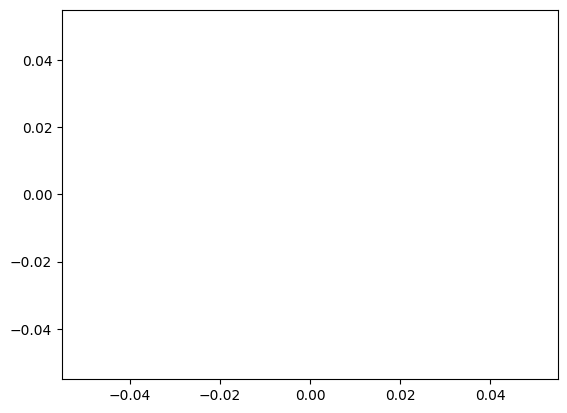

In [63]:
plt.plot(lossi)

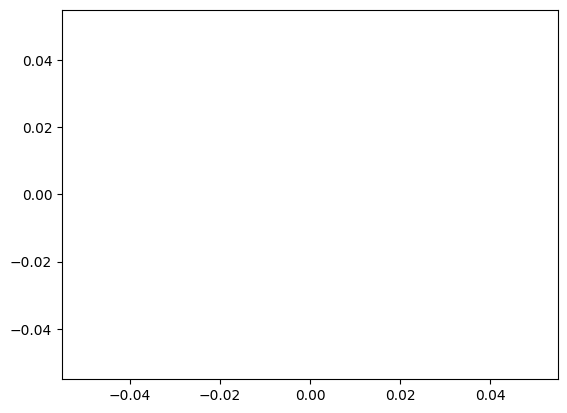

In [64]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [65]:
for layer in layers:
  layer.training = False

In [66]:
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  x = emb.view(emb.shape[0],-1) # birlestirme islemi concat (N,block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x,y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.2848715782165527
val 3.2858572006225586


In [89]:
##################################
##################################
##################################
##################################
##################################


#--------------------------------------------------------------
# C embedding table layer classinin icinde olmadigi icin onu gomuyoruz. C nin yaptigi sey temel olarak embedding ve flatten oldugu icin bunlarin fonksiyonlarini tanimliyoruz


In [95]:
torch.manual_seed(42)

In [157]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive: # karpathy burada FlattenConsecutive implementasyonu ile torchun
# parametre acisindan ayrildigini soyluyor, torch flattenda (start_dim,end_dim) parametreleri var

  def __init__(self,n): # task3e gectik burada
    self.n = n # task3e gectik burada

  def __call__(self, x):
    B,T,C = x.shape
    x = x.view(x.shape[0], T//self.n,C*self.n) # burada yaptigimiz matrisimizi n e boluoruz
    # tensor (B,T,C) den (B,T/n, C*n) e geciyor
    # yani 8li block_sizei tek seferde flat etmektense 2serli parcalara boluyoruz
    if x.shape[1]==1: # yani flatten_size = block_Size esitse parcaya ayirmaya gerek yok
      x = x.squeeze(1) # yani matris (B,C) formuna indirgeniyor
    self.out = x
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]


In [165]:
# modeli tekrardan tanimlayalim
n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size,n_embd),
    # FlattenConsecutive(block_size), # FlattenConsecutive(8) oldugunda WaveNet= MLP oluyor performans kazanci yok,
    # Linear(n_embd*block_size,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(), # bias= false cunku
    FlattenConsecutive(2),Linear(n_embd*2,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    #batch normdan gelen parametre 1. layer biasi iptal ediyor
    Linear(n_hidden,vocab_size),
])

# parametre baslangici
with torch.no_grad():
  layers[-1].weight *= 0.1 # sert baslangici hafifletmek icin

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # total parametre sayisi
for p in parameters:
  p.requires_grad = True


76579


In [166]:
ix = torch.randint(0, Xtr.shape[0], (4,))
logits = model(Xtr[ix])
for layer in model.layers:
  print(layer.__class__.__name__,  ':', tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


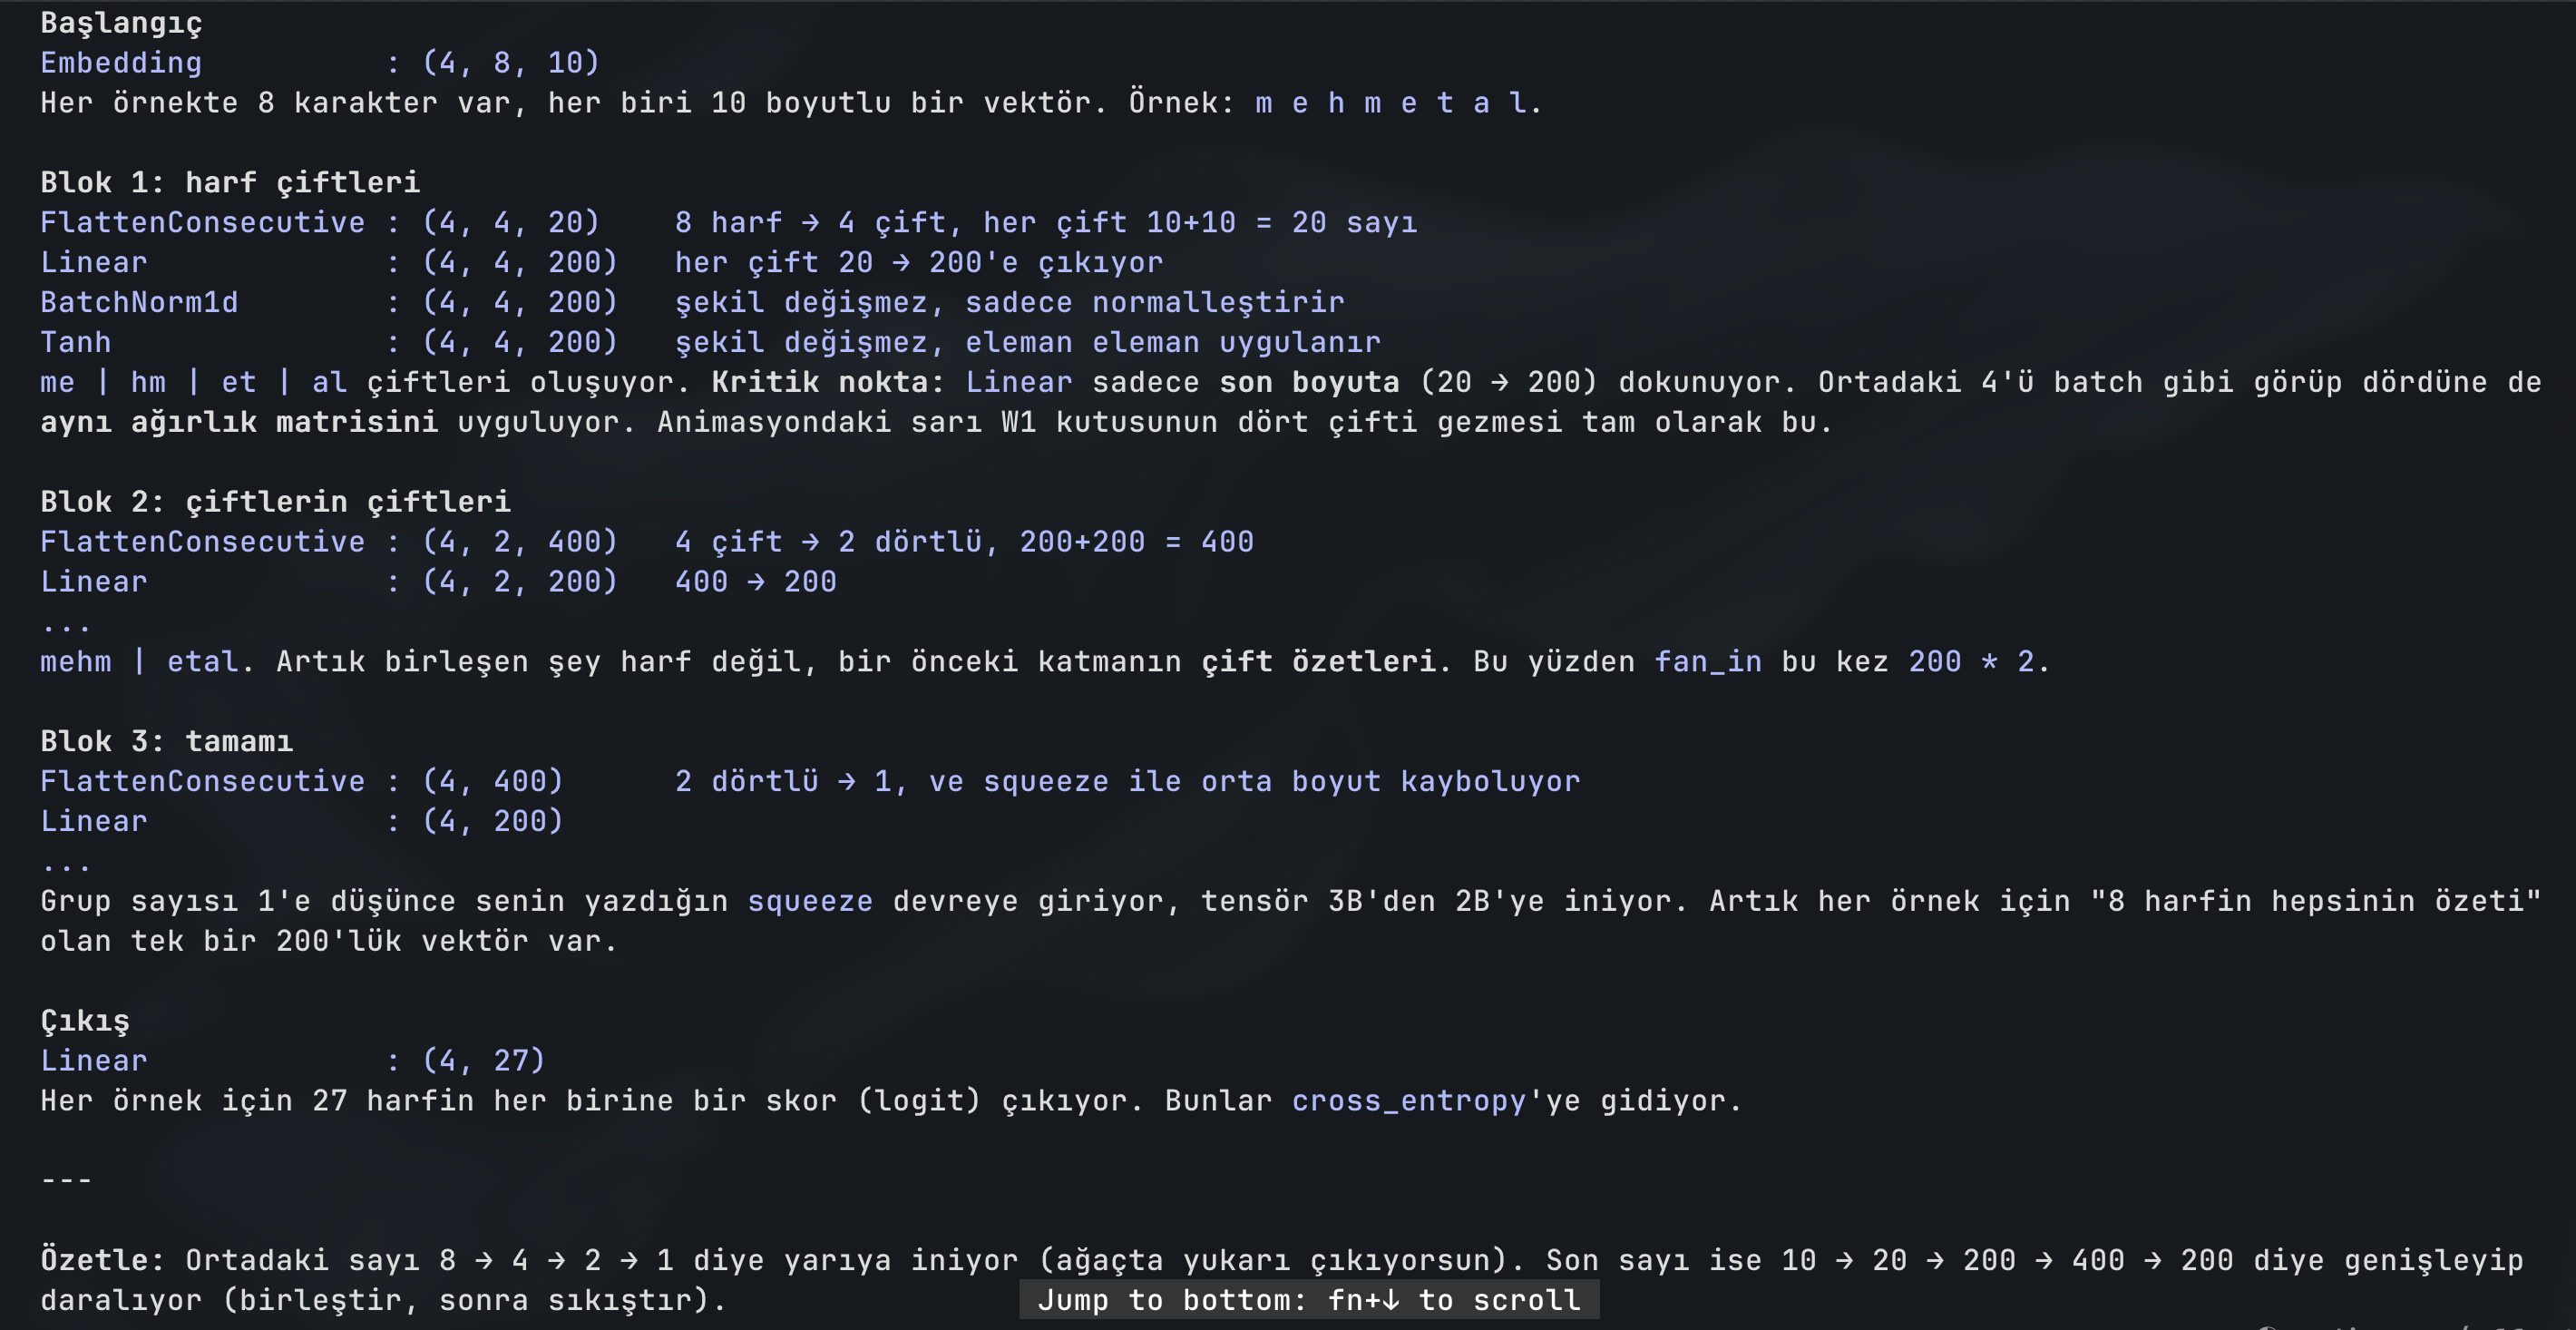

In [167]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y


  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function


  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.4841
  10000/ 200000: 2.3415
  20000/ 200000: 2.1092
  30000/ 200000: 2.0028
  40000/ 200000: 1.7152
  50000/ 200000: 1.7749
  60000/ 200000: 2.2122
  70000/ 200000: 1.5670
  80000/ 200000: 1.8234
  90000/ 200000: 1.9777
 100000/ 200000: 1.9201
 110000/ 200000: 2.2009
 120000/ 200000: 2.2820
 130000/ 200000: 2.0053
 140000/ 200000: 1.5815
 150000/ 200000: 2.0348
 160000/ 200000: 1.6959
 170000/ 200000: 1.6417
 180000/ 200000: 1.9471
 190000/ 200000: 1.5793


In [168]:
for layer in model.layers:
  layer.training = False

In [169]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7690587043762207
val 1.9886969327926636


## task 2
2. Bağlamı 3 harften 8'e çıkar. Başka hiçbir şeyi değiştirmeden aynı düz modeli koş, dev loss'u kaydet. Bu senin karşılaştırma tabanın. Parametre sayısı ne kadar arttı, loss ne kadar düştü, yaz. (17:11 - 21:36)

In [ ]:
# -------- 8 block_size degerleri MLP
# train 1.9179668426513672
# val 2.0245304107666016


# 3 block_size degerleri
# train 2.05
# val 2.10




## task 3
3. WaveNet'i kur. 8 harfi tek seferde düzleştirmek yerine ikişer ikişer birleştir, üç katmanda tek vektöre in. Her katmanın çıktısının şeklini yazdır ve o şeklin neden öyle olduğunu kendi cümlelerinle yaz. (21:36 - 37:41)



In [109]:
# burada manim kullanarak aradaki farki kisaca gosteren bir demo hazirladim

!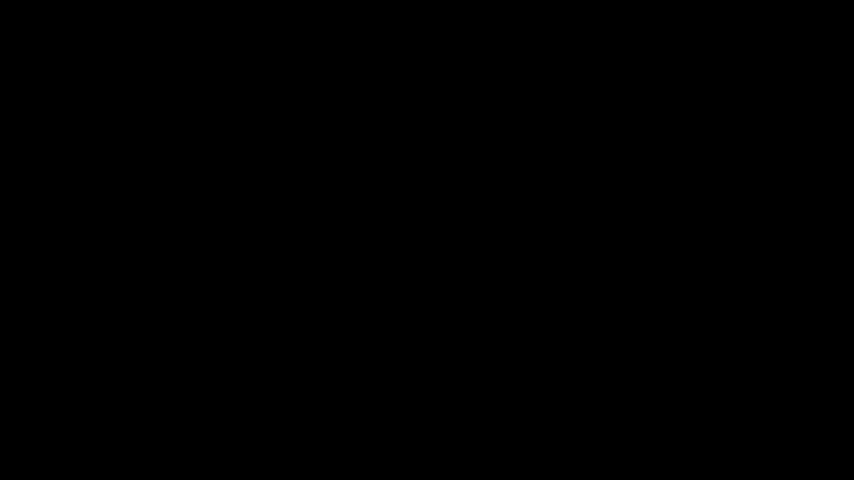[gif](1.gif)

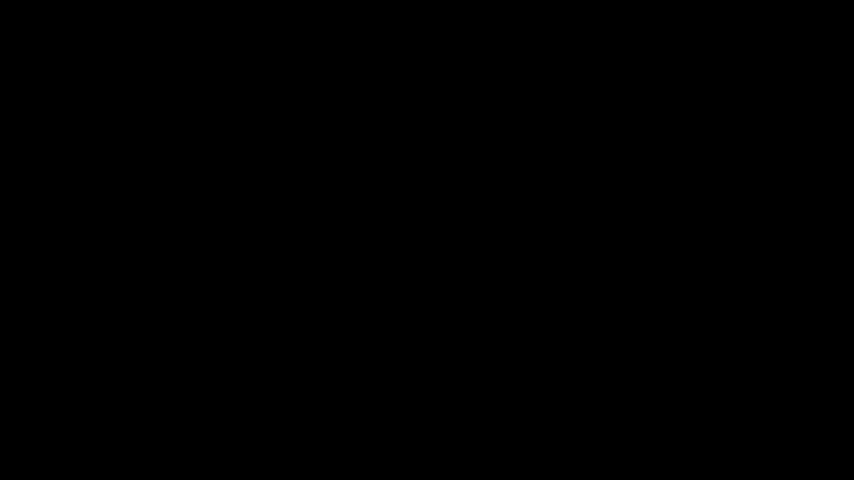

In [116]:
ix = torch.randint(0, Xtr.shape[0], (4,)) # let's look at a batch of just 4 examples
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0, 16, 18,  9, 19,  9, 12],
        [ 0,  0,  0, 12,  5, 12,  1, 14],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 11,  1, 20,  9]])

In [117]:
model.layers[0].out.shape # output of embedding layer

torch.Size([4, 8, 10])

In [118]:
model.layers[1].out.shape # output of Flatten layer # yapmak istediigmiz 4 ,80 yerine 4,4,20

torch.Size([4, 80])

In [119]:
model.layers[2].out.shape # output of linear layer

torch.Size([4, 200])

## task 4
4. Şekilleri yazdırırken BatchNorm1d'nin üç boyutlu girdide yanlış çalıştığını göreceksin. Hatanın ne olduğunu ve ortalamanın hangi eksenlerde alınması gerektiğini göster, düzelt, modeli yeniden eğit. Düzeltmeden önceki ve sonraki dev loss'u yan yana koy. (37:41 - 46:07)

In [ ]:
# Wavenet 8 train 1.772289514541626
# val 1.9803340435028076 bugli hali


# wavenet 8 train 1.736472249031067
# val 1.9930024147033691 bugsiz hali

# wavenet 8 train ama hidden layer ve emb dimension arttirildi
#train 1.7690587043762207
#val 1.9886969327926636

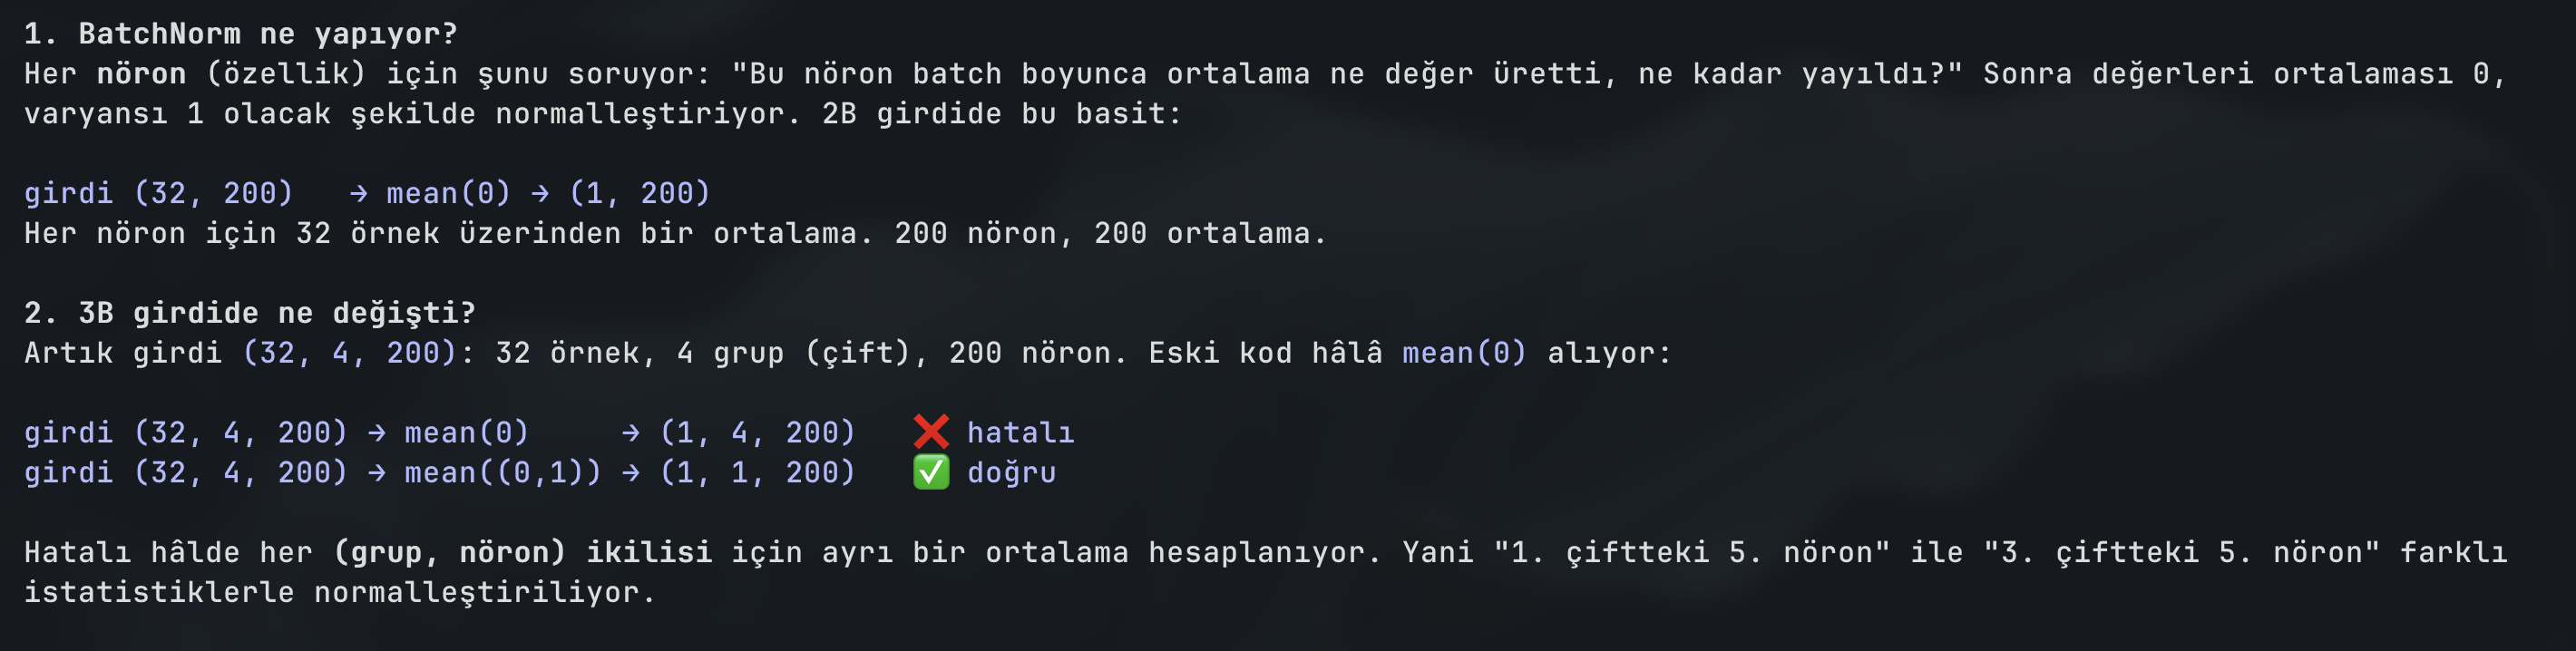

In [ ]:
# oznitelik cikariz ya o yuzden her ciftin toplam ortalamasini almali ayri ayri degil

In [ ]:
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word